# Stage 1: Setup & Configuration


### 1.1 Import Libraries
We start by importing all libraries needed for PyTorch model building, dataset transformations, data science visualizations, and system utilities.


In [31]:
# Future imports for type annotations compatibility
from __future__ import annotations

# Import built-in Python modules
import os
import gc
import random
import time
import zipfile
import json
import hashlib
from pathlib import Path

# Configure PyTorch CUDA memory allocator to reduce fragmentation on GPUs
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True,max_split_size_mb:128")

# Import third-party scientific computing and plotting libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

# Import PyTorch core modules
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader

# Import torchvision for pre-built models and image transforms
from torchvision import datasets, models, transforms

# Import machine learning evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Import progress bar library
from tqdm.auto import tqdm



### 1.2 Define Hyperparameters & Directories
Here we configure our dataset path search, image resolutions, batch sizes, worker counts, and toggles for which models to train.


In [32]:
# Define global constants for reproducibility
SEED = 42
MAX_TRAIN_IMAGES_PER_CLASS = None  # Cap train images per class for smoke testing (e.g. set to 50 for quick test)
MAX_TEST_IMAGES_PER_CLASS = None   # Cap test images per class for smoke testing (e.g. set to 25 for quick test)
VALIDATION_SPLIT = 0.15            # Fraction of train data set aside for validation
RESNET_IMAGE_SIZE = 224            # Input resolution for Custom CNN, ResNet10, ResNet18, and ResNet50
EFFICIENTNET_IMAGE_SIZE = 288      # Input resolution for EfficientNetB3

# Setup paths for data directories and artifact storage
DATA_DIR = Path("/kaggle/working/food101_data")
INPUT_ROOT = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")
EXPORT_DIR = WORK_DIR / "foody_food101_transfer_artifacts"
MODEL_DIR = EXPORT_DIR / "models"
RESULTS_DIR = EXPORT_DIR / "results"
SAMPLE_DIR = EXPORT_DIR / "samples"

# Create directories if they do not exist
for path in [DATA_DIR, EXPORT_DIR, MODEL_DIR, RESULTS_DIR, SAMPLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Define model runtime performance configurations
GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
KAGGLE_CRASH_SAFE_MODE = True      # Prevents memory crashes on low-resource environments (like Kaggle free tier)
USE_DATA_PARALLEL = False if KAGGLE_CRASH_SAFE_MODE else GPU_COUNT > 1
PER_GPU_BATCH_224 = 64             # Batch size for 224px input models (scratch CNN, ResNet)
PER_GPU_BATCH_288 = 32 if KAGGLE_CRASH_SAFE_MODE else 64  # Batch size for EfficientNetB3

# Calculate global batch sizes based on available GPUs and DataParallel configuration
BATCH_SIZE_224 = PER_GPU_BATCH_224 * max(1, GPU_COUNT if USE_DATA_PARALLEL else 1)
BATCH_SIZE_288 = PER_GPU_BATCH_288 * max(1, GPU_COUNT if USE_DATA_PARALLEL else 1)
GRAD_ACCUM_STEPS_224 = 1
GRAD_ACCUM_STEPS_288 = 1

# Configure multi-threaded loading workers
NUM_WORKERS = 0 if KAGGLE_CRASH_SAFE_MODE else min(2, os.cpu_count() or 2)
PREFETCH_FACTOR = 2

# Model training toggle switches
RUN_CUSTOM_CNN = True
RUN_CUSTOM_RESNET10 = True
RUN_RESNET18 = True
RUN_RESNET50 = True
RUN_EFFICIENTNET_B3 = True

# Epoch counts and hyperparameter flags
CUSTOM_CNN_EPOCHS = 8
CUSTOM_RESNET10_EPOCHS = 8
RESNET18_EPOCHS = 10
RESNET50_EPOCHS = 10
EFFICIENTNET_B3_HEAD_EPOCHS = 4
EFFICIENTNET_B3_FINE_TUNE_EPOCHS = 12
EFFICIENTNET_FINE_TUNE_BLOCKS = 3
PATIENCE = 4                       # Early stopping patience: epochs to wait for val_acc improvement

ARTIFACT_VERSION = "foody-food101-v3"
AUTO_REUSE_MATCHING_RUNS = True    # Reuses cached weights/metrics if config is identical
SAVE_EPOCH_CHECKPOINTS = True
USE_AMP = True                     # Automatic Mixed Precision for faster CUDA training
USE_CHANNELS_LAST = torch.cuda.is_available() and not KAGGLE_CRASH_SAFE_MODE
ALLOW_FOOD101_DOWNLOAD = True
RECOMMENDED_FOOD101_KAGGLE_DATASET = "https://www.kaggle.com/datasets/crybread/food101"



### 1.3 Random Seed & Performance optimizations
We guarantee reproducibility by pinning our random seeds across python, numpy, and PyTorch. We also configure performance optimizations (TF32 and CuDNN benchmark).


In [33]:
# Function to set random seeds for numpy, random, and PyTorch (CPU and CUDA)
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Initialize seed and performance optimization parameters
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = torch.cuda.is_available()

# Enable FP32/TF32 matmul options for performance on RTX architecture GPUs
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

print("Device Selected:", device)
print("GPU Count Available:", GPU_COUNT)



Device Selected: cuda
GPU Count Available: 2


# Stage 2: Dataset Acquisition


### 2.1 Dataset Helpers
Here we define helper functions to check the correct image and meta subfolders layout of our target dataset.


In [34]:
# Helper function to check if a directory has the correct Food-101 dataset folder structure
def has_food101_layout(path: Path) -> bool:
    # A standard Food-101 layout must contain 'images' and 'meta' directories
    return (path / "images").is_dir() and (path / "meta").is_dir()

# Helper function to list mounted Kaggle inputs
def attached_input_roots() -> list[Path]:
    if not INPUT_ROOT.exists():
        return []
    # Return a list of all immediate subdirectories inside /kaggle/input
    return sorted(path for path in INPUT_ROOT.iterdir() if path.is_dir())

# Helper function to search directories shallowly to avoid deep recursions in large directories
def shallow_dirs(root: Path, max_depth: int = 3) -> list[Path]:
    found: list[Path] = []
    stack = [(root, 0)]
    while stack:
        current, depth = stack.pop()
        found.append(current)
        if depth >= max_depth:
            continue
        try:
            stack.extend((child, depth + 1) for child in current.iterdir() if child.is_dir())
        except OSError:
            pass
    return found



### 2.2 Scan & Acquire Dataset
We scan candidate folders for Food-101, and if missing, download it from the official servers using torchvision.


In [35]:
# Helper function to scan files and locate the Food-101 root directory
def find_food101_root() -> Path | None:
    # List of candidate paths locally and on Kaggle
    candidates = [
        DATA_DIR / "food-101",
        Path("c:/Users/KIRA/Desktop/notebooks/food101_data/food-101"),
        Path("C:/Users/sahil/Downloads/archive (1)/food-101"),
        Path("/kaggle/input/food-101/food-101"),
        Path("/kaggle/input/food101/food-101"),
        Path("/kaggle/input/food-101"),
        Path("/kaggle/input/food101"),
    ]
    # Check candidates first
    for candidate in candidates:
        if has_food101_layout(candidate):
            return candidate
    # Perform shallow search under attached inputs if not found
    for dataset_root in attached_input_roots():
        for candidate in shallow_dirs(dataset_root, max_depth=4):
            if has_food101_layout(candidate):
                return candidate
    return None

# Helper message to assist users when data is missing
def food101_missing_message() -> str:
    attached = attached_input_roots()
    attached_text = "\n  ".join(str(path) for path in attached) or "none"
    return (
        "Food-101 dataset was not found locally, and automatic download failed/is disabled.\n"
        f"Please mount the Kaggle dataset: {RECOMMENDED_FOOD101_KAGGLE_DATASET}\n"
        "Or make sure the folder is placed in the workspace under food101_data.\n"
        "Expected directory layout contains 'images/' and 'meta/'.\n"
        f"Checked mounted input roots: {attached_text}"
    )

# Locate or download the dataset
food101_root = find_food101_root()
if food101_root is None:
    if not ALLOW_FOOD101_DOWNLOAD:
        raise RuntimeError(food101_missing_message())
    print("Food-101 not found. Downloading via torchvision...")
    try:
        # Trigger torchvision automatic downloader for train and test splits
        datasets.Food101(root=str(DATA_DIR), split="train", download=True)
        datasets.Food101(root=str(DATA_DIR), split="test", download=True)
        food101_root = DATA_DIR / "food-101"
    except Exception as exc:
        raise RuntimeError(food101_missing_message()) from exc

# Validate located path
if not has_food101_layout(food101_root):
    raise RuntimeError(food101_missing_message())

print("Food-101 Dataset successfully located at:", food101_root)



Food-101 Dataset successfully located at: /kaggle/working/food101_data/food-101


# Stage 3: Manifest Creation & Data Splitting


### 3.1 Class Parsing & manifest building
We read class names, map them to class indices, and build helper functions to parse official split lists into pandas DataFrames.


In [36]:
# Helper function to read stripped non-empty lines from text files (like class lists)
def read_lines(path: Path) -> list[str]:
    return [line.strip() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]

# Load official class names and map them to indices
class_names = read_lines(food101_root / "meta" / "classes.txt")
class_to_idx = {name: index for index, name in enumerate(class_names)}
NUM_CLASSES = len(class_names)

# Helper function to construct structured metadata lists
def make_rows(split_name: str, image_ids: list[str]) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for image_id in image_ids:
        class_name = image_id.split("/")[0]
        rows.append({
            "source_split": split_name,
            "image_id": image_id,
            "class_name": class_name,
            "label": class_to_idx[class_name],
            "image_path": str(food101_root / "images" / f"{image_id}.jpg"),
        })
    return pd.DataFrame(rows)

# Helper function to cap classes for rapid prototyping/testing
def cap_per_class(frame: pd.DataFrame, cap: int | None) -> pd.DataFrame:
    if cap is None:
        return frame.reset_index(drop=True)
    return (
        frame.groupby("class_name", group_keys=False)
        .apply(lambda group: group.sample(n=min(cap, len(group)), random_state=SEED))
        .reset_index(drop=True)
    )



### 3.2 Splitting Data into Train, Validation, and Test
We load the official train and test file lists, cap them if requested for testing, and split the training split into 85% Train and 15% Validation.


In [37]:
# Load official splits from text files
official_train = make_rows("official_train", read_lines(food101_root / "meta" / "train.txt"))
official_test = make_rows("official_test", read_lines(food101_root / "meta" / "test.txt"))

# Apply caps if configured
official_train = cap_per_class(official_train, MAX_TRAIN_IMAGES_PER_CLASS)
official_test = cap_per_class(official_test, MAX_TEST_IMAGES_PER_CLASS)

# Stratify the training set to make a training split (85%) and validation split (15%)
train_df, val_df = train_test_split(
    official_train,
    test_size=VALIDATION_SPLIT,
    random_state=SEED,
    stratify=official_train["label"]  # Ensures balanced classes in train and validation sets
)
test_df = official_test.copy()

# Add split designation columns and merge into a single manifest
train_df = train_df.assign(split="train").reset_index(drop=True)
val_df = val_df.assign(split="val").reset_index(drop=True)
test_df = test_df.assign(split="test").reset_index(drop=True)
manifest = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Export splitting results to disk
manifest.to_csv(RESULTS_DIR / "food101_manifest.csv", index=False)
(MODEL_DIR / "class_names.json").write_text(json.dumps(class_names, indent=2), encoding="utf-8")

# Output splitting summary table
summary_df = manifest.groupby("split").size().to_frame("images_count")
print(summary_df)



       images_count
split              
test          25250
train         64387
val           11363


# Stage 4: Visual Exploratory Data Analysis (EDA)


### 4.1 Check Class Balance
We verify that the training images are evenly distributed across food categories to avoid learning biases.


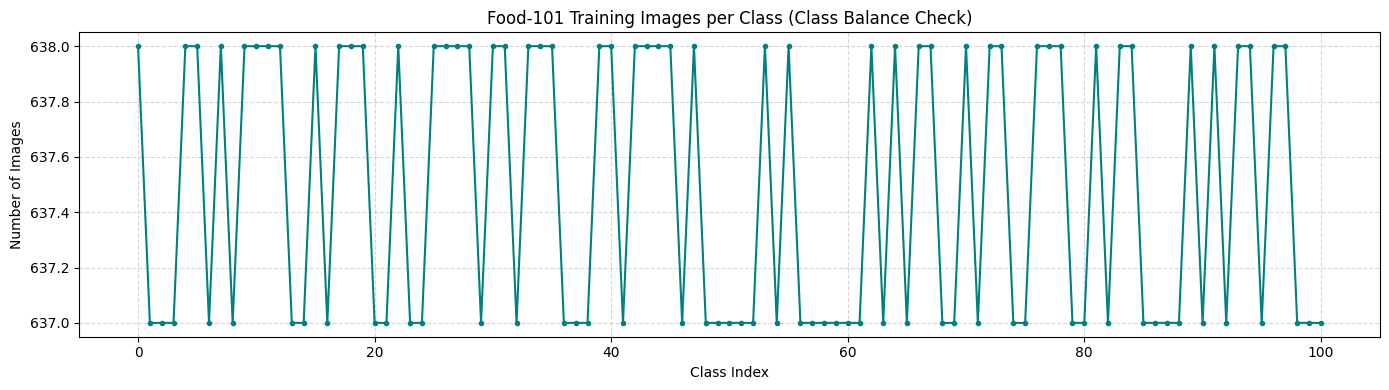

In [38]:
# Plot the distribution of classes in the training set
plt.figure(figsize=(14, 4))
class_counts = train_df["class_name"].value_counts().sort_index()
plt.plot(range(len(class_counts)), class_counts.values, marker='.', color='teal')
plt.title("Food-101 Training Images per Class (Class Balance Check)")
plt.xlabel("Class Index")
plt.ylabel("Number of Images")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "class_distribution.png", dpi=160)
plt.show()



### 4.2 Preview Sample Images
We plot a grid of random food images from the dataset and print their category titles to verify input loading.


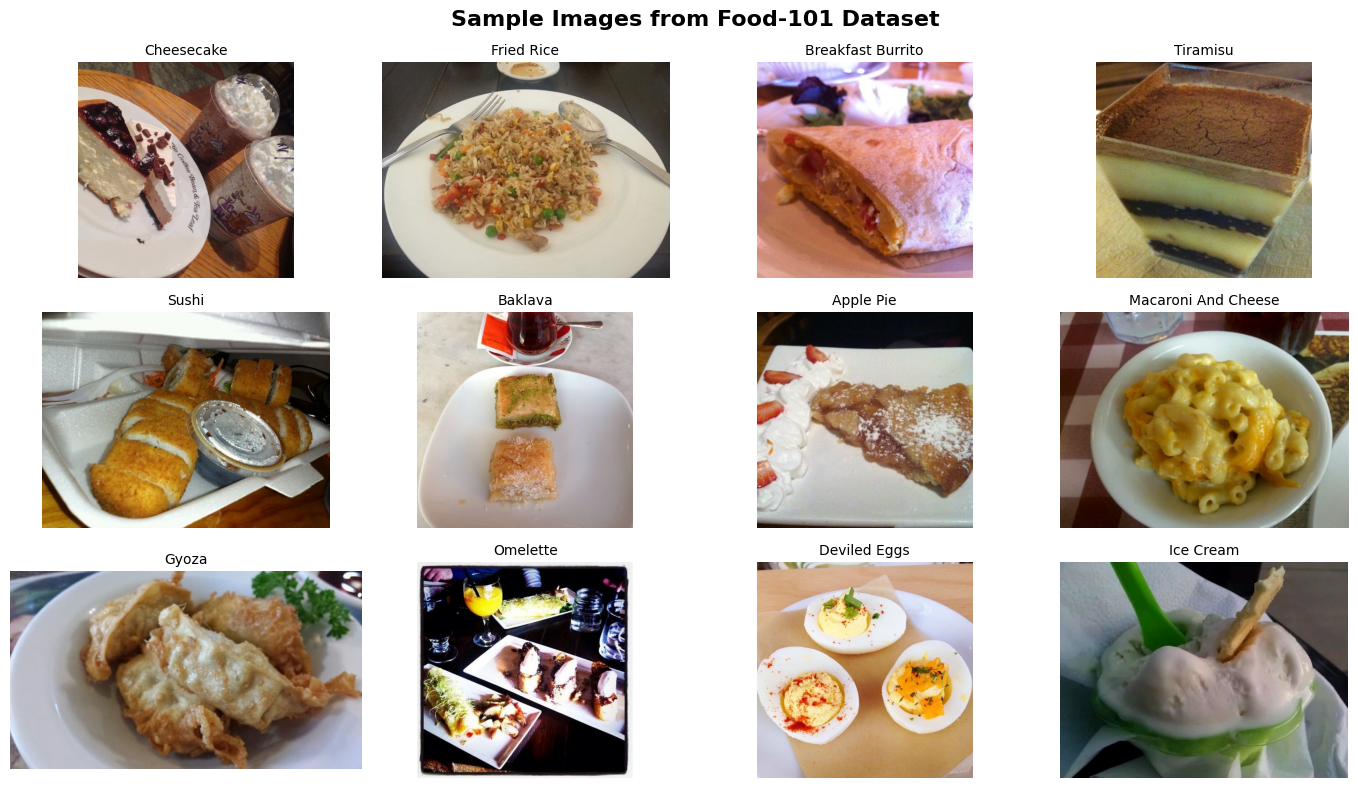

In [39]:
# Display a grid of sample food images from our training set
sample_rows = train_df.groupby("class_name").head(1).head(12)  # Grab first sample of first 12 classes
plt.figure(figsize=(14, 8))
for index, (_, row) in enumerate(sample_rows.iterrows(), start=1):
    image_path = row["image_path"]
    image = Image.open(image_path).convert("RGB")
    
    plt.subplot(3, 4, index)
    plt.imshow(image)
    # Convert category name (e.g. 'french_fries') to formatted title (e.g. 'French Fries')
    plt.title(row["class_name"].replace("_", " ").title(), fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Images from Food-101 Dataset", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(SAMPLE_DIR / "food101_samples.png", dpi=160)
plt.show()



# Stage 5: Data Transforms & Augmentation


### 5.1 Image Normalization & 224px Transforms
We define standard ImageNet statistics, and write augmentation pipelines for our 224px models (custom CNN, ResNet).


In [40]:
# ImageNet standard normalization constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Data pipelines for 224px models (Custom CNN, ResNet18, ResNet50)
transforms_224 = {
    "train": transforms.Compose([
        transforms.Resize((RESNET_IMAGE_SIZE, RESNET_IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),           # 50% chance to flip horizontally
        transforms.RandomRotation(degrees=15),             # Randomly rotate image by +/- 15 degrees
        transforms.ToTensor(),                             # Convert PIL Image to PyTorch Tensor [0.0, 1.0]
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)  # Scale tensor values based on ImageNet metrics
    ]),
    "eval": transforms.Compose([
        transforms.Resize((RESNET_IMAGE_SIZE, RESNET_IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
}



### 5.2 288px Transforms for EfficientNetB3
EfficientNetB3 expects larger resolutions. We define a 288px input augmentation pipeline with scale-aware cropping and color jittering.


In [41]:
# Data pipelines for 288px model (EfficientNetB3)
transforms_288 = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(EFFICIENTNET_IMAGE_SIZE, scale=(0.7, 1.0)), # Scale-invariant crop
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        # Color jitter adjusts brightness, contrast, saturation, and hue to teach lighting invariance
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
    "eval": transforms.Compose([
        # EfficientNet center cropping pipeline
        transforms.Resize(320),
        transforms.CenterCrop(EFFICIENTNET_IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    ]),
}

print("Transforms successfully initialized.")



Transforms successfully initialized.


# Stage 6: PyTorch Datasets & DataLoaders


### 6.1 Custom PyTorch Dataset
We implement the `Food101FrameDataset` class to fetch images and labels from our split dataframes and apply transforms.


In [42]:
# Define a custom Dataset class to read from our manifest DataFrame
class Food101FrameDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform) -> None:
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, int]:
        # Extract row metadata
        row = self.frame.iloc[index]
        image_path = row["image_path"]
        label = int(row["label"])
        
        # Load image and force conversion to RGB format (drops alpha channels)
        image = Image.open(image_path).convert("RGB")
        
        # Apply transforms (Augmentation or Normalization)
        if self.transform is not None:
            image = self.transform(image)
            
        return image, label



### 6.2 DataLoader Builder
We define a helper function to wrap our dataset into optimized PyTorch `DataLoader` instances with pinned memory.


In [43]:
# Helper function to construct a PyTorch DataLoader
def make_loader(frame: pd.DataFrame, transform, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = Food101FrameDataset(frame, transform)
    kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": torch.cuda.is_available()  # Speeds up tensor transfer to GPU
    }
    # Add performance optimization flags if workers are active
    if NUM_WORKERS > 0:
        kwargs.update({
            "persistent_workers": True,
            "prefetch_factor": PREFETCH_FACTOR
        })
    return DataLoader(dataset, **kwargs)



### 6.3 Instantiate Loaders
We build data loaders for both 224px (CNN/ResNet) and 288px (EfficientNet) splits.


In [44]:
# Build DataLoaders for 224px input models
loaders_224 = {
    "train": make_loader(train_df, transforms_224["train"], BATCH_SIZE_224, shuffle=True),
    "val": make_loader(val_df, transforms_224["eval"], BATCH_SIZE_224, shuffle=False),
    "test": make_loader(test_df, transforms_224["eval"], BATCH_SIZE_224, shuffle=False),
}

# Build DataLoaders for 288px input models (EfficientNetB3)
loaders_288 = {
    "train": make_loader(train_df, transforms_288["train"], BATCH_SIZE_288, shuffle=True),
    "val": make_loader(val_df, transforms_288["eval"], BATCH_SIZE_288, shuffle=False),
    "test": make_loader(test_df, transforms_288["eval"], BATCH_SIZE_288, shuffle=False),
}

# Record size statistics
dataset_sizes = {"train": len(train_df), "val": len(val_df), "test": len(test_df)}
print("Loaders built successfully. Training images:", dataset_sizes["train"])



Loaders built successfully. Training images: 64387


# Stage 7: Model Architectures


### 7.1 Reusable Layer Blocks
We define reusable blocks: a `ConvNormAct` convolutional block and a `ResidualBlock` with skip connection paths.


In [45]:
# A helper block: Convolution -> Batch Normalization -> Activation (SiLU)
class ConvNormAct(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1) -> None:
        super().__init__()
        # Bias is disabled because Batch Normalization cancels it
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

# Standard Residual Block for ResNet
class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1) -> None:
        super().__init__()
        # Convolution branch F(x)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.act1 = nn.SiLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut connection path (projection shortcut if channels or resolution changes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
        self.act2 = nn.SiLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # F(x) calculation
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        # F(x) + x skip connection
        out += self.shortcut(x)
        # Apply final activation
        return self.act2(out)



### 7.2 Foody Custom CNN (Scratch Baseline)
We define our first baseline model: a compact convolutional network trained from scratch.


In [46]:
# Custom Convolutional Neural Network built from scratch
class FoodyCustomCNN(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super().__init__()
        # Sequential convolution feature extractor
        self.features = nn.Sequential(
            ConvNormAct(3, 32, stride=2),  # Downsamples input 224 -> 112
            ConvNormAct(32, 64),
            ConvNormAct(64, 64, stride=2),  # Downsamples 112 -> 56
            ConvNormAct(64, 128),
            ConvNormAct(128, 128, stride=2), # Downsamples 56 -> 28
            ConvNormAct(128, 256),
            ConvNormAct(256, 256, stride=2), # Downsamples 28 -> 14
            nn.AdaptiveAvgPool2d(1)          # Global average pooling: reduces 14x14 feature maps to 1x1
        )
        # Classification head mapping 256 feature vectors to class counts
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.35),
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))

def build_custom_cnn(num_classes: int) -> nn.Module:
    return FoodyCustomCNN(num_classes)



### 7.3 Custom ResNet10 (Scratch ResNet Baseline)
We implement our second baseline: a custom ResNet10 designed from scratch to teach residual shortcut mappings.


In [47]:
# Custom ResNet10 architecture from scratch (1 initial conv + 4 residual blocks * 2 convs + 1 fully connected = 10 layers)
class CustomResNet10(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super().__init__()
        # Initial convolutional input layer
        self.in_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        # Four residual stages (1 block each)
        self.layer1 = ResidualBlock(64, 64, stride=1)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        self.layer4 = ResidualBlock(256, 512, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.in_conv(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

def build_custom_resnet10(num_classes: int) -> nn.Module:
    return CustomResNet10(num_classes)



### 7.4 Pretrained ResNet18 & ResNet50
We define model loaders for ResNet18 and ResNet50. We freeze their convolutional layers and replace their output layer for transfer learning.


In [48]:
def build_resnet18(num_classes: int) -> nn.Module:
    try:
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    except Exception:
        model = models.resnet18(pretrained=True)
    # Freeze all feature backbone layers
    for parameter in model.parameters():
        parameter.requires_grad = False
    # Replace last layer with classification output layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def build_resnet50(num_classes: int) -> nn.Module:
    try:
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    except Exception:
        model = models.resnet50(pretrained=True)
    # Freeze backbone
    for parameter in model.parameters():
        parameter.requires_grad = False
    # Replace linear layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model



### 7.5 Pretrained EfficientNetB3
We load EfficientNetB3 and replace its linear layer, mapping the features to 101 food class predictions.


In [49]:
def build_efficientnet_b3(num_classes: int) -> nn.Module:
    try:
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
    except Exception:
        model = models.efficientnet_b3(pretrained=True)
    # Replace classifier layer
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

# Configuration helper for EfficientNet fine-tuning stages
def set_efficientnet_trainable(model: nn.Module, phase: str) -> None:
    base = unwrap_model(model)
    # Freeze the entire network by default
    for parameter in base.parameters():
        parameter.requires_grad = False
    # Unfreeze classifier parameters
    for parameter in base.classifier.parameters():
        parameter.requires_grad = True
    # Unfreeze final features blocks for fine-tuning phase
    if phase == "fine_tune":
        for block in base.features[-EFFICIENTNET_FINE_TUNE_BLOCKS:]:
            for parameter in block.parameters():
                parameter.requires_grad = True



### 7.6 Model Deployment Helpers
We define model device allocation, image normalization formats, parameter counters, and unwrap utilities.


In [50]:
# Helper to count parameters requiring updates
def count_trainable(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in unwrap_model(model).parameters() if parameter.requires_grad)

# Helper to unwrap DataParallel wrappers if applied
def unwrap_model(model: nn.Module) -> nn.Module:
    return model.module if isinstance(model, nn.DataParallel) else model

# Helper to apply model device placement
def prepare_model(model: nn.Module) -> nn.Module:
    if USE_CHANNELS_LAST and device.type == "cuda":
        model = model.to(device, memory_format=torch.channels_last)
    else:
        model = model.to(device)
    if USE_DATA_PARALLEL:
        model = nn.DataParallel(model)
    return model

# Helper to optimize tensor placement
def move_images(images: torch.Tensor) -> torch.Tensor:
    images = images.to(device, non_blocking=True)
    if USE_CHANNELS_LAST and device.type == "cuda":
        images = images.contiguous(memory_format=torch.channels_last)
    return images



# Stage 8: Unified Training Loop & Caching


### 8.1 Caching & Memory Cleaning Utilities
We define caching configurations and model file location builders to save trained checkpoints and prevent redundant GPU processing.


In [51]:
# Cross entropy loss with label smoothing to prevent overconfidence in predictions
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

# Free GPU memory cache blocks
def clear_cuda() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Generate a fingerprint hash for configuration validation
def config_hash(payload: dict[str, object]) -> str:
    serialized = json.dumps(payload, sort_keys=True, default=str)
    return hashlib.sha256(serialized.encode("utf-8")).hexdigest()[:16]

# Read JSON configurations
def load_json_file(path: Path) -> dict[str, object] | None:
    if not path.exists():
        return None
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except json.JSONDecodeError:
        return None

# Functions to return path definitions for metrics, run metadata, and histories
def model_metadata_path(model_name: str) -> Path:
    return RESULTS_DIR / f"{model_name}_run_metadata.json"

def model_metrics_path(model_name: str) -> Path:
    return RESULTS_DIR / f"{model_name}_metrics.json"

def model_history_path(model_name: str) -> Path:
    return RESULTS_DIR / f"{model_name}_history.csv"



### 8.2 Epoch Runner
We define `run_epoch`, which handles a single forward/backward pass with optional gradient updates and AMP autocasting.


In [52]:
# Core single-epoch runner function
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer | None = None,
    scaler: GradScaler | None = None,
    grad_accum_steps: int = 1,
) -> tuple[float, float]:
    is_training = optimizer is not None
    model.train(is_training)
    
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    steps_per_update = max(1, int(grad_accum_steps))

    if is_training and optimizer is not None:
        optimizer.zero_grad(set_to_none=True)

    # Disable gradient tracking when validating
    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for step, (images, labels) in enumerate(tqdm(loader, leave=False, desc="Processing Batches"), start=1):
            images = move_images(images)
            labels = labels.to(device, non_blocking=True)

            # Apply AMP autocast when running on CUDA
            with autocast(enabled=USE_AMP and device.type == "cuda"):
                outputs = model(images)
                raw_loss = criterion(outputs, labels)
                loss = raw_loss / steps_per_update

            if is_training and optimizer is not None:
                if scaler is not None and scaler.is_enabled():
                    # AMP scale loss and backpropagation
                    scaler.scale(loss).backward()
                    if step % steps_per_update == 0 or step == len(loader):
                        scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        scaler.step(optimizer)
                        scaler.update()
                        optimizer.zero_grad(set_to_none=True)
                else:
                    # Regular backpropagation
                    loss.backward()
                    if step % steps_per_update == 0 or step == len(loader):
                        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        optimizer.step()
                        optimizer.zero_grad(set_to_none=True)

            # Record running metrics
            batch_size = labels.size(0)
            total_loss += raw_loss.detach().item() * batch_size
            total_correct += (outputs.argmax(dim=1) == labels).sum().item()
            total_examples += batch_size
            
            del images, labels, outputs, raw_loss, loss

    return total_loss / max(total_examples, 1), total_correct / max(total_examples, 1)



### 8.3 Caching & Training supervisor
We define `train_model`, which coordinates epochs, early stopping, and handles model weight updates.


In [53]:
# Build runtime configuration parameter dictionary
def build_run_config(model_name: str, image_size: int, batch_size: int, grad_accum_steps: int, epochs: int, notes: str) -> dict[str, object]:
    return {
        "artifact_version": ARTIFACT_VERSION,
        "model_name": model_name,
        "dataset": "Food-101",
        "num_classes": NUM_CLASSES,
        "class_names_hash": config_hash({"classes": class_names}),
        "train_images": len(train_df),
        "val_images": len(val_df),
        "test_images": len(test_df),
        "max_train_images_per_class": MAX_TRAIN_IMAGES_PER_CLASS,
        "max_test_images_per_class": MAX_TEST_IMAGES_PER_CLASS,
        "validation_split": VALIDATION_SPLIT,
        "image_size": image_size,
        "batch_size": batch_size,
        "gradient_accumulation_steps": grad_accum_steps,
        "effective_batch_size": batch_size * grad_accum_steps,
        "epochs": epochs,
        "amp": USE_AMP,
        "channels_last": USE_CHANNELS_LAST,
        "seed": SEED,
        "notes": notes,
    }

# Attempt to load a model run if cached on disk
def try_load_cached_model(model: nn.Module, model_name: str, save_path: Path, run_config: dict[str, object]) -> tuple[pd.DataFrame, dict[str, object]] | None:
    run_hash = config_hash(run_config)
    metadata = load_json_file(model_metadata_path(model_name))
    metrics = load_json_file(model_metrics_path(model_name))
    
    # Check if configurations match cached values
    if not AUTO_REUSE_MATCHING_RUNS or metadata is None or metrics is None or not save_path.exists():
        return None
    if metadata.get("config_hash") != run_hash:
        print(f"Cache fingerprint mismatch for {model_name}. Retraining...")
        return None
        
    # Load weights
    state_dict = torch.load(save_path, map_location=device)
    unwrap_model(model).load_state_dict(state_dict, strict=True)
    
    # Retrieve metrics history
    history_path = model_history_path(model_name)
    history_df = pd.read_csv(history_path) if history_path.exists() else pd.DataFrame()
    metrics["reused_cache"] = True
    print(f"Loaded {model_name} from cache. Test accuracy: {float(metrics.get('test_accuracy', 0.0)):.4f}")
    return history_df, metrics

# Export configuration metadata
def save_run_metadata(model_name: str, run_config: dict[str, object], metrics: dict[str, object]) -> None:
    payload = {
        "config_hash": config_hash(run_config),
        "config": run_config,
        "metrics": metrics,
        "saved_at_unix": time.time(),
    }
    model_metadata_path(model_name).write_text(json.dumps(payload, indent=2), encoding="utf-8")

# Move weights to CPU to save GPU memory
def offload_model(model: nn.Module) -> nn.Module:
    model.to("cpu")
    clear_cuda()
    return model

# Prepare loaded models for inference
def activate_model_for_inference(model: nn.Module) -> nn.Module:
    model = model.to(device)
    if USE_CHANNELS_LAST and device.type == "cuda":
        model = model.to(memory_format=torch.channels_last)
    model.eval()
    return model

# Training control framework function
def train_model(
    model: nn.Module,
    loaders: dict[str, DataLoader],
    optimizer: optim.Optimizer,
    scheduler,
    epochs: int,
    save_path: Path,
    model_name: str,
    grad_accum_steps: int,
) -> tuple[nn.Module, pd.DataFrame, float]:
    save_path.parent.mkdir(parents=True, exist_ok=True)
    scaler = GradScaler(enabled=USE_AMP and device.type == "cuda")
    best_acc = -1.0
    stale_epochs = 0
    history: list[dict[str, float]] = []
    started = time.time()

    for epoch in range(1, epochs + 1):
        # Run training phase
        train_loss, train_acc = run_epoch(model, loaders["train"], optimizer, scaler, grad_accum_steps)
        # Run validation phase
        val_loss, val_acc = run_epoch(model, loaders["val"])
        
        # Step the scheduler to adjust learning rates
        if scheduler is not None:
            scheduler.step()

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
        })
        
        pd.DataFrame(history).to_csv(model_history_path(model_name), index=False)
        if SAVE_EPOCH_CHECKPOINTS:
            (RESULTS_DIR / f"{model_name}_latest_epoch.json").write_text(json.dumps(history[-1], indent=2), encoding="utf-8")
            
        print(f"[{model_name}] Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        # Save model parameters if validation accuracy improves
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(unwrap_model(model).state_dict(), save_path)
            stale_epochs = 0
            print(f"Saved best model checkpoint to {save_path}")
        else:
            stale_epochs += 1
            if stale_epochs >= PATIENCE:
                print(f"Early stopping triggered. Model did not improve for {stale_epochs} epochs.")
                break

    # Load best checkpoint before returning
    unwrap_model(model).load_state_dict(torch.load(save_path, map_location=device), strict=True)
    history_df = pd.DataFrame(history)
    history_df.to_csv(model_history_path(model_name), index=False)
    return model, history_df, time.time() - started



### 8.4 Evaluation & metrics generation
We define evaluation helpers to load model predictions and output detailed reports (macro F1-scores, training speed).


In [54]:
# Evaluate model performance on the test split
def predict_loader(model: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    labels_all: list[int] = []
    preds_all: list[int] = []
    conf_all: list[float] = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Inference Step", leave=False):
            images = move_images(images)
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predictions = probabilities.max(dim=1)
            
            labels_all.extend(labels.numpy().tolist())
            preds_all.extend(predictions.cpu().numpy().tolist())
            conf_all.extend(confidence.cpu().numpy().tolist())
            
    return np.array(labels_all), np.array(preds_all), np.array(conf_all)

# Save reports and generate metrics profiles
def evaluate_and_save(model_name: str, model: nn.Module, loader: DataLoader, training_seconds: float, run_config: dict[str, object]) -> dict[str, object]:
    labels, preds, confidences = predict_loader(model, loader)
    accuracy = float((labels == preds).mean())
    report = classification_report(labels, preds, labels=list(range(NUM_CLASSES)), target_names=class_names, output_dict=True, zero_division=0)
    report_text = classification_report(labels, preds, labels=list(range(NUM_CLASSES)), target_names=class_names, zero_division=0)
    
    (RESULTS_DIR / f"{model_name}_classification_report.txt").write_text(report_text, encoding="utf-8")
    (RESULTS_DIR / f"{model_name}_classification_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
    
    metrics = {
        "model": model_name,
        "test_accuracy": accuracy,
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "weighted_f1": float(report["weighted avg"]["f1-score"]),
        "mean_confidence": float(confidences.mean()) if len(confidences) else 0.0,
        "trainable_parameters": count_trainable(model),
        "training_seconds": round(training_seconds, 2),
        "config_hash": config_hash(run_config),
        "reused_cache": False,
    }
    model_metrics_path(model_name).write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    return metrics



# Stage 9: Training Execution


### 9.1 General Model Stage Runner
We define the `run_model_stage` controller, which sets up the optimizer, registers standard models, and invokes training loops.


In [55]:
# Define run variables
results: list[dict[str, object]] = []
trained_models: dict[str, tuple[nn.Module, dict[str, DataLoader]]] = {}

# Standard model training manager
def run_model_stage(
    model_name: str,
    builder,
    loaders: dict[str, DataLoader],
    image_size: int,
    batch_size: int,
    grad_accum_steps: int,
    epochs: int,
    save_filename: str,
    lr: float,
    scheduler_gamma: float,
    notes: str,
) -> None:
    clear_cuda()
    save_path = MODEL_DIR / save_filename
    run_config = build_run_config(model_name, image_size, batch_size, grad_accum_steps, epochs, notes)
    
    # Initialize model
    model = prepare_model(builder(NUM_CLASSES))
    cached = try_load_cached_model(model, model_name, save_path, run_config)
    
    if cached is None:
        print(f"--- Training Model Stage: {model_name} ---")
        # Define AdamW optimizer and StepLR scheduler
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
        scheduler = lr_scheduler.StepLR(optimizer, step_size=5, gamma=scheduler_gamma)
        
        # Run training loop
        model, history_df, training_seconds = train_model(model, loaders, optimizer, scheduler, epochs, save_path, model_name, grad_accum_steps)
        metrics = evaluate_and_save(model_name, model, loaders["test"], training_seconds, run_config)
        save_run_metadata(model_name, run_config, metrics)
        del optimizer, scheduler
    else:
        history_df, metrics = cached
        
    model = offload_model(model)
    results.append(metrics)
    trained_models[model_name] = (model, loaders)



### 9.2 Two-Phase Champion Stage Runner (EfficientNetB3)
We define the `run_efficientnet_b3_stage` controller, implementing warmup and top layer fine-tuning steps.


In [56]:
# Custom two-phase manager for EfficientNetB3
def run_efficientnet_b3_stage() -> None:
    clear_cuda()
    model_name = "EfficientNetB3"
    save_path = MODEL_DIR / "EfficientNetB3_best.pth"
    total_epochs = EFFICIENTNET_B3_HEAD_EPOCHS + EFFICIENTNET_B3_FINE_TUNE_EPOCHS
    notes = f"head warmup {EFFICIENTNET_B3_HEAD_EPOCHS} epochs, then fine-tune last {EFFICIENTNET_FINE_TUNE_BLOCKS} feature blocks"
    run_config = build_run_config(model_name, EFFICIENTNET_IMAGE_SIZE, BATCH_SIZE_288, GRAD_ACCUM_STEPS_288, total_epochs, notes)
    
    model = prepare_model(build_efficientnet_b3(NUM_CLASSES))
    cached = try_load_cached_model(model, model_name, save_path, run_config)
    
    if cached is None:
        print(f"--- Training Model Stage: {model_name} (Phase 1: Classifier Warmup) ---")
        # Phase 1: Warmup classifier head while keeping backbone layers frozen
        set_efficientnet_trainable(model, "head")
        optimizer_head = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4, weight_decay=1e-4)
        scheduler_head = lr_scheduler.StepLR(optimizer_head, step_size=3, gamma=0.5)
        
        model, _, _ = train_model(
            model, loaders_288, optimizer_head, scheduler_head, 
            EFFICIENTNET_B3_HEAD_EPOCHS, MODEL_DIR / "EfficientNetB3_head_best.pth", "EfficientNetB3_head", GRAD_ACCUM_STEPS_288
        )
        del optimizer_head, scheduler_head
        clear_cuda()

        print(f"--- Training Model Stage: {model_name} (Phase 2: Fine-Tuning) ---")
        # Phase 2: Unfreeze top layers and run full learning iterations
        set_efficientnet_trainable(model, "fine_tune")
        optimizer_eff = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5, weight_decay=1e-4)
        scheduler_eff = lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=max(1, EFFICIENTNET_B3_FINE_TUNE_EPOCHS))
        
        model, history_df, training_seconds = train_model(
            model, loaders_288, optimizer_eff, scheduler_eff, 
            EFFICIENTNET_B3_FINE_TUNE_EPOCHS, save_path, model_name, GRAD_ACCUM_STEPS_288
        )
        torch.save(unwrap_model(model).state_dict(), MODEL_DIR / "EfficientNetB3_final.pth")
        metrics = evaluate_and_save(model_name, model, loaders_288["test"], training_seconds, run_config)
        save_run_metadata(model_name, run_config, metrics)
        del optimizer_eff, scheduler_eff
    else:
        history_df, metrics = cached
        
    model = offload_model(model)
    results.append(metrics)
    trained_models[model_name] = (model, loaders_288)



### 9.3 Train Custom CNN
We execute training for our custom convolutional network baseline.


In [57]:
# Execute Custom CNN stage
if RUN_CUSTOM_CNN:
    run_model_stage(
        model_name="CustomCNN",
        builder=build_custom_cnn,
        loaders=loaders_224,
        image_size=RESNET_IMAGE_SIZE,
        batch_size=BATCH_SIZE_224,
        grad_accum_steps=GRAD_ACCUM_STEPS_224,
        epochs=CUSTOM_CNN_EPOCHS,
        save_filename="CustomCNN_best.pth",
        lr=1e-3,
        scheduler_gamma=0.5,
        notes="scratch Custom CNN baseline at 224px",
    )



--- Training Model Stage: CustomCNN ---


/tmp/ipykernel_57/1928700358.py:86: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP and device.type == "cuda")


Processing Batches:   0%|          | 0/1007 [00:00<?, ?it/s]

/tmp/ipykernel_57/53610182.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP and device.type == "cuda"):


Processing Batches:   0%|          | 0/178 [00:00<?, ?it/s]

...

[CustomCNN] Epoch 07/8 | train_loss=2.9756 train_acc=0.3311 | val_loss=2.8570 val_acc=0.3643
Saved best model checkpoint to /kaggle/working/foody_food101_transfer_artifacts/models/CustomCNN_best.pth


Processing Batches:   0%|          | 0/1007 [00:00<?, ?it/s]

Processing Batches:   0%|          | 0/178 [00:00<?, ?it/s]

[CustomCNN] Epoch 08/8 | train_loss=2.8866 train_acc=0.3564 | val_loss=2.7960 val_acc=0.3767
Saved best model checkpoint to /kaggle/working/foody_food101_transfer_artifacts/models/CustomCNN_best.pth


Inference Step:   0%|          | 0/395 [00:00<?, ?it/s]

### 9.4 Train Custom ResNet10
We train our custom ResNet10 to evaluate performance of skip connections built from scratch.


In [58]:
# Execute Custom ResNet10 stage
if RUN_CUSTOM_RESNET10:
    run_model_stage(
        model_name="CustomResNet10",
        builder=build_custom_resnet10,
        loaders=loaders_224,
        image_size=RESNET_IMAGE_SIZE,
        batch_size=BATCH_SIZE_224,
        grad_accum_steps=GRAD_ACCUM_STEPS_224,
        epochs=CUSTOM_RESNET10_EPOCHS,
        save_filename="CustomResNet10_best.pth",
        lr=1e-3,
        scheduler_gamma=0.5,
        notes="scratch Custom ResNet10 skip-connection baseline at 224px",
    )



--- Training Model Stage: CustomResNet10 ---


/tmp/ipykernel_57/1928700358.py:86: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP and device.type == "cuda")


Processing Batches:   0%|          | 0/1007 [00:00<?, ?it/s]

/tmp/ipykernel_57/53610182.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP and device.type == "cuda"):


Processing Batches:   0%|          | 0/178 [00:00<?, ?it/s]

...

[CustomResNet10] Epoch 07/8 | train_loss=2.1020 train_acc=0.5463 | val_loss=2.2187 val_acc=0.5208
Saved best model checkpoint to /kaggle/working/foody_food101_transfer_artifacts/models/CustomResNet10_best.pth


Processing Batches:   0%|          | 0/1007 [00:00<?, ?it/s]

Processing Batches:   0%|          | 0/178 [00:00<?, ?it/s]

[CustomResNet10] Epoch 08/8 | train_loss=1.9981 train_acc=0.5735 | val_loss=2.2371 val_acc=0.5176


Inference Step:   0%|          | 0/395 [00:00<?, ?it/s]

### 9.5 Train Pretrained ResNet18
We train our frozen ResNet18 transfer baseline.


In [59]:
# Execute ResNet18 stage
if RUN_RESNET18:
    run_model_stage(
        model_name="ResNet18",
        builder=build_resnet18,
        loaders=loaders_224,
        image_size=RESNET_IMAGE_SIZE,
        batch_size=BATCH_SIZE_224,
        grad_accum_steps=GRAD_ACCUM_STEPS_224,
        epochs=RESNET18_EPOCHS,
        save_filename="ResNet18_best.pth",
        lr=1e-3,
        scheduler_gamma=0.5,
        notes="frozen ImageNet ResNet18 backbone with Food-101 classifier head",
    )



Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 226MB/s]

--- Training Model Stage: ResNet18 ---



/tmp/ipykernel_57/1928700358.py:86: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP and device.type == "cuda")


Processing Batches:   0%|          | 0/1007 [00:00<?, ?it/s]

...

[ResNet18] Epoch 09/10 | train_loss=2.2478 train_acc=0.5116 | val_loss=2.3748 val_acc=0.4893


Processing Batches:   0%|          | 0/1007 [00:00<?, ?it/s]

Processing Batches:   0%|          | 0/178 [00:00<?, ?it/s]

[ResNet18] Epoch 10/10 | train_loss=2.2376 train_acc=0.5158 | val_loss=2.3742 val_acc=0.4914


Inference Step:   0%|          | 0/395 [00:00<?, ?it/s]

### 9.6 Train Pretrained ResNet50
We train our deeper ResNet50 residual network.


In [60]:
# Execute ResNet50 stage
if RUN_RESNET50:
    run_model_stage(
        model_name="ResNet50",
        builder=build_resnet50,
        loaders=loaders_224,
        image_size=RESNET_IMAGE_SIZE,
        batch_size=BATCH_SIZE_224,
        grad_accum_steps=GRAD_ACCUM_STEPS_224,
        epochs=RESNET50_EPOCHS,
        save_filename="ResNet50_best.pth",
        lr=1e-3,
        scheduler_gamma=0.1,
        notes="frozen ImageNet ResNet50 backbone with Food-101 classifier head",
    )



Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


--- Training Model Stage: ResNet50 ---


/tmp/ipykernel_57/1928700358.py:86: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP and device.type == "cuda")


Processing Batches:   0%|          | 0/1007 [00:00<?, ?it/s]

...

[ResNet50] Epoch 09/10 | train_loss=1.6202 train_acc=0.6917 | val_loss=1.8963 val_acc=0.6117


Processing Batches:   0%|          | 0/1007 [00:00<?, ?it/s]

Processing Batches:   0%|          | 0/178 [00:00<?, ?it/s]

[ResNet50] Epoch 10/10 | train_loss=1.6141 train_acc=0.6918 | val_loss=1.8894 val_acc=0.6153
Saved best model checkpoint to /kaggle/working/foody_food101_transfer_artifacts/models/ResNet50_best.pth


Inference Step:   0%|          | 0/395 [00:00<?, ?it/s]

### 9.7 Train Pretrained EfficientNetB3
We execute the training sequence for our scaled champion: EfficientNetB3.


In [61]:
# Execute EfficientNetB3 stage
if RUN_EFFICIENTNET_B3:
    run_efficientnet_b3_stage()



Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 194MB/s]


--- Training Model Stage: EfficientNetB3 (Phase 1: Classifier Warmup) ---


/tmp/ipykernel_57/1928700358.py:86: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP and device.type == "cuda")


Processing Batches:   0%|          | 0/2013 [00:00<?, ?it/s]

...

[EfficientNetB3] Epoch 11/12 | train_loss=1.1434 train_acc=0.8108 | val_loss=1.2080 val_acc=0.7940


Processing Batches:   0%|          | 0/2013 [00:00<?, ?it/s]

Processing Batches:   0%|          | 0/356 [00:00<?, ?it/s]

[EfficientNetB3] Epoch 12/12 | train_loss=1.1370 train_acc=0.8136 | val_loss=1.2045 val_acc=0.7942


Inference Step:   0%|          | 0/790 [00:00<?, ?it/s]

# Stage 10: Quantitative Comparison


### 10.1 Display Metrics Comparison
We load all model training results into a pandas DataFrame and display it.


In [62]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(results).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)

# Display tabular summaries
print("--- Quantitative Model Evaluation Chart ---")
print(comparison_df.to_string(columns=["model", "test_accuracy", "macro_f1", "trainable_parameters", "training_seconds"]))



--- Quantitative Model Evaluation Chart ---
            model  test_accuracy  macro_f1  trainable_parameters  training_seconds
0  EfficientNetB3       0.840277  0.839196               8661315          14494.35
1        ResNet50       0.662614  0.659118                206949           4777.92
2  CustomResNet10       0.567010  0.561690               4957605           3605.02
3        ResNet18       0.532752  0.525072                 51813           3986.16
4       CustomCNN       0.405980  0.391877               1189893           3635.86


### 10.2 Accuracy Bar Plot
We generate a comparative bar plot showing the test accuracies of all architectures side-by-side.


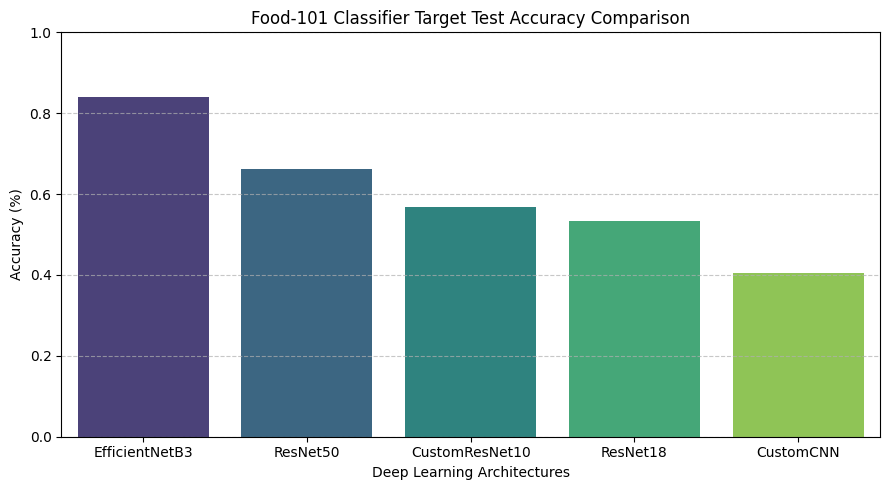

Top Performing Architecture Selected: EfficientNetB3


In [63]:
# Plot accuracy bars
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_df, x="model", y="test_accuracy", hue="model", legend=False, palette="viridis")
plt.ylim(0, 1.0)
plt.title("Food-101 Classifier Target Test Accuracy Comparison")
plt.xlabel("Deep Learning Architectures")
plt.ylabel("Accuracy (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison.png", dpi=160)
plt.show()

# Define overall best classifier
best_model_name = str(comparison_df.iloc[0]["model"])
best_model, best_loaders = trained_models[best_model_name]
best_model = activate_model_for_inference(best_model)
print(f"Top Performing Architecture Selected: {best_model_name}")



# Stage 11: Qualitative Diagnostics


### 11.1 Plot Confusion Matrix
We run inference on the test dataset to compute and display a confusion matrix heatmap.


Inference Step:   0%|          | 0/790 [00:00<?, ?it/s]

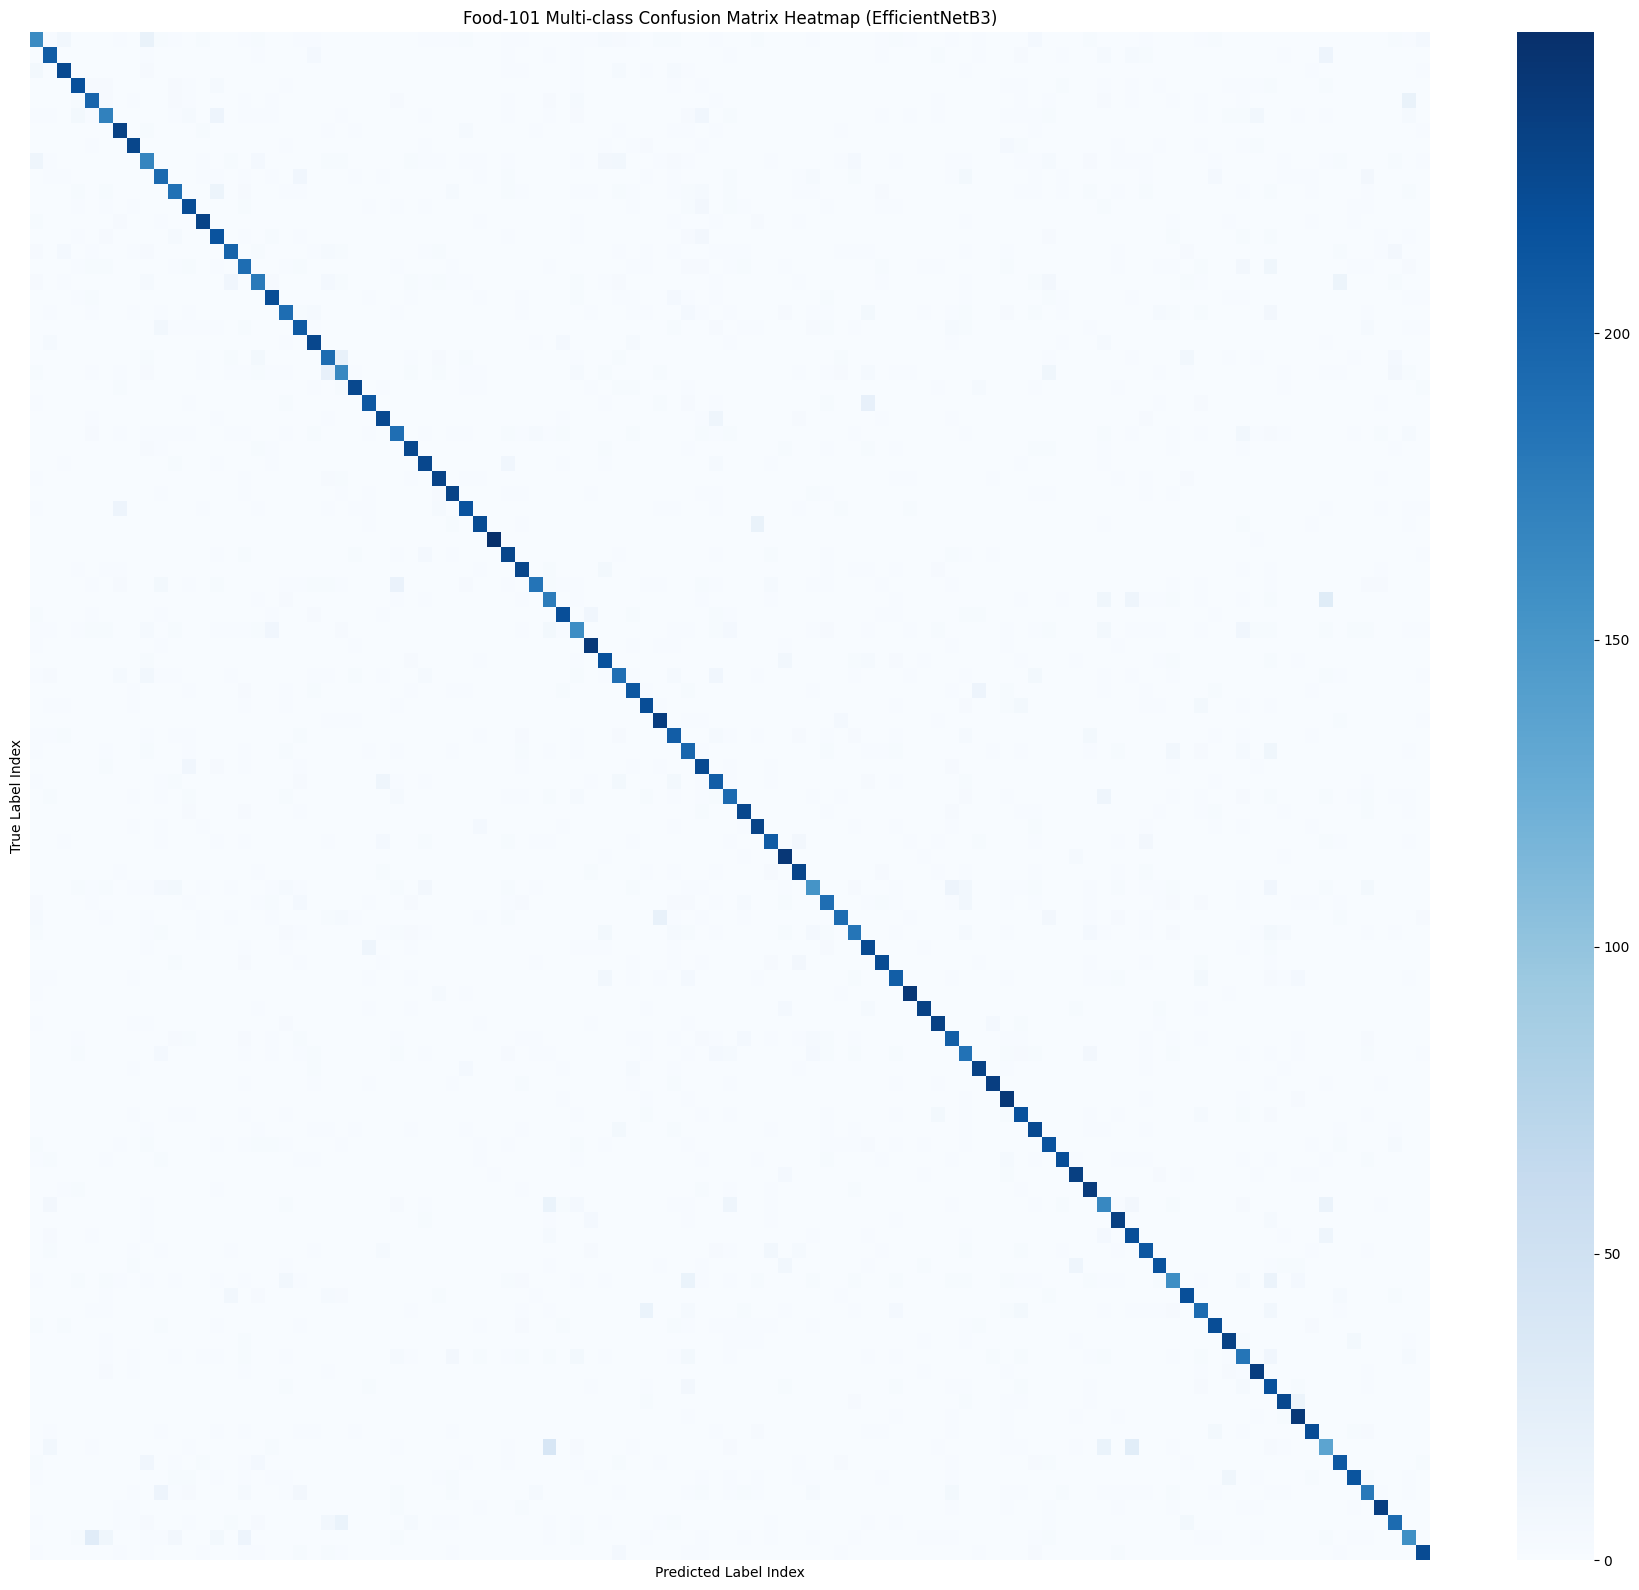

In [64]:
# Generate predictions for the best model on test dataset
best_labels, best_preds, best_confidences = predict_loader(best_model, best_loaders["test"])

# Build Confusion Matrix
cm = confusion_matrix(best_labels, best_preds, labels=list(range(NUM_CLASSES)))

# Plot Confusion Matrix heatmap
plt.figure(figsize=(18, 16))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title(f"Food-101 Multi-class Confusion Matrix Heatmap ({best_model_name})")
plt.xlabel("Predicted Label Index")
plt.ylabel("True Label Index")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "best_confusion_matrix.png", dpi=180)
plt.show()



### 11.2 Save Classification Report
We generate detailed classification reports (precision, recall) and print a snippet of the results.


In [65]:
# Export final classification reports
best_report = classification_report(best_labels, best_preds, labels=list(range(NUM_CLASSES)), target_names=class_names, zero_division=0)
(RESULTS_DIR / "best_classification_report.txt").write_text(best_report, encoding="utf-8")

# Print first 2000 characters of reports to verify output format
print("--- Classification Report Diagnostics (Preview) ---")
print(best_report[:2000])



--- Classification Report Diagnostics (Preview) ---
                         precision    recall  f1-score   support

              apple_pie       0.72      0.65      0.68       250
         baby_back_ribs       0.83      0.83      0.83       250
                baklava       0.91      0.90      0.90       250
         beef_carpaccio       0.89      0.87      0.88       250
           beef_tartare       0.79      0.79      0.79       250
             beet_salad       0.80      0.69      0.74       250
               beignets       0.87      0.93      0.90       250
               bibimbap       0.92      0.91      0.91       250
          bread_pudding       0.67      0.67      0.67       250
      breakfast_burrito       0.76      0.78      0.77       250
             bruschetta       0.79      0.74      0.77       250
           caesar_salad       0.84      0.89      0.87       250
                cannoli       0.93      0.92      0.93       250
          caprese_salad       0.79   

# Stage 12: Inference & Predict Contract


### 12.1 Inference Processor
We write `predict_dish_from_path`, which pre-processes a single test image and outputs predictions with confidence.


In [66]:
# Helper function to convert raw class tags to user-friendly titles
def display_name(class_name: str) -> str:
    return class_name.replace("_", " ").title()

# Helper function to return correct image shape configurations
def best_model_image_size() -> int:
    return EFFICIENTNET_IMAGE_SIZE if best_model_name == "EfficientNetB3" else RESNET_IMAGE_SIZE

# Single image inference processor
def predict_dish_from_path(image_path: str | Path, model: nn.Module = best_model) -> dict[str, object]:
    image_size = best_model_image_size()
    # Select appropriate evaluation transforms
    transform = transforms_288["eval"] if image_size == EFFICIENTNET_IMAGE_SIZE else transforms_224["eval"]
    
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0)
    
    model.eval()
    with torch.no_grad():
        outputs = model(move_images(tensor))
        probabilities = torch.softmax(outputs, dim=1)[0]
        confidence, prediction = torch.max(probabilities, dim=0)
        
    class_name = class_names[int(prediction.item())]
    return {
        "class_name": class_name,
        "dish_name": display_name(class_name),
        "confidence": float(confidence.item()),
    }



### 12.2 Single-image Test Run
We run a sample inference verification on our test set.


In [67]:
# Run sample test prediction
sample_image = Path(test_df.iloc[0]["image_path"])
sample_prediction = predict_dish_from_path(sample_image)
print("Target Sample Image Tested:", sample_image)
print("Output Prediction Results:", sample_prediction)



Target Sample Image Tested: /kaggle/working/food101_data/food-101/images/apple_pie/1011328.jpg
Output Prediction Results: {'class_name': 'gyoza', 'dish_name': 'Gyoza', 'confidence': 0.44141295552253723}


### 12.3 Export Model Contract
We export the configuration registries (`model_registry.json`) detailing weights paths and normalization stats for RAG api consumption.


In [68]:
# Construct RAG deployment registry contract
model_registry = {
    "task": "food101_classification",
    "recipe_generation": "backend_rag_api",
    "best_model": best_model_name,
    "models": {
        "CustomCNN": {
            "architecture": "FoodyCustomCNN",
            "weights": "models/CustomCNN_best.pth",
            "image_size": RESNET_IMAGE_SIZE,
            "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
            "purpose": "scratch baseline for comparison",
        },
        "CustomResNet10": {
            "architecture": "CustomResNet10",
            "weights": "models/CustomResNet10_best.pth",
            "image_size": RESNET_IMAGE_SIZE,
            "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
            "purpose": "scratch skip-connection validation model",
        },
        "ResNet18": {
            "architecture": "torchvision.models.resnet18",
            "weights": "models/ResNet18_best.pth",
            "image_size": RESNET_IMAGE_SIZE,
            "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
        },
        "ResNet50": {
            "architecture": "torchvision.models.resnet50",
            "weights": "models/ResNet50_best.pth",
            "image_size": RESNET_IMAGE_SIZE,
            "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
        },
        "EfficientNetB3": {
            "architecture": "torchvision.models.efficientnet_b3",
            "weights": "models/EfficientNetB3_best.pth",
            "image_size": EFFICIENTNET_IMAGE_SIZE,
            "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
        },
    },
    "classes": "models/class_names.json",
    "rag_contract": {
        "input": "dish_name from classifier",
        "output": "recipe, substitutions, nutrition discussion, and chat answer from the app RAG/API",
    },
    "sample_prediction": sample_prediction,
}

# Export registry configurations to disk
(MODEL_DIR / "model_registry.json").write_text(json.dumps(model_registry, indent=2), encoding="utf-8")
(MODEL_DIR / "rag_recipe_contract.json").write_text(json.dumps(model_registry["rag_contract"], indent=2), encoding="utf-8")
print("RAG model contract generated successfully.")



RAG model contract generated successfully.


# Stage 13: Packaging & Zip Export


### 13.1 Save Training Config
We write our final run configurations to a JSON parameters manifest file.


In [69]:
# Save final summary configuration dictionary
training_config = {
    "artifact_version": ARTIFACT_VERSION,
    "dataset": "Food-101",
    "food101_root": str(food101_root),
    "num_classes": NUM_CLASSES,
    "classes_file": "models/class_names.json",
    "best_model": best_model_name,
    "max_train_images_per_class": MAX_TRAIN_IMAGES_PER_CLASS,
    "max_test_images_per_class": MAX_TEST_IMAGES_PER_CLASS,
    "validation_split": VALIDATION_SPLIT,
    "batch_size_224": BATCH_SIZE_224,
    "batch_size_288": BATCH_SIZE_288,
    "grad_accum_steps_224": GRAD_ACCUM_STEPS_224,
    "grad_accum_steps_288": GRAD_ACCUM_STEPS_288,
    "effective_batch_224": BATCH_SIZE_224 * GRAD_ACCUM_STEPS_224,
    "effective_batch_288": BATCH_SIZE_288 * GRAD_ACCUM_STEPS_288,
    "efficientnet_strategy": "head warmup, then last-block fine-tuning to avoid memory crashes",
    "auto_reuse_matching_runs": AUTO_REUSE_MATCHING_RUNS,
    "models_trained": [row["model"] for row in results],
    "recipe_generation": "Use the Foody frontend/backend RAG API.",
}

(MODEL_DIR / "training_config.json").write_text(json.dumps(training_config, indent=2), encoding="utf-8")



812

### 13.2 Zip Exporter
Finally, we pack weights, charts, and metrics JSON files into a zip package for backend integration.


In [70]:
# Compress exporter directory
zip_path = WORK_DIR / "foody_food101_transfer_artifacts.zip"
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(EXPORT_DIR.rglob("*")):
        if path.is_file():
            archive.write(path, path.relative_to(EXPORT_DIR.parent))

print("Created artifacts package successfully at:", zip_path)
print("Artifact summary files list (First 15 items):")
for path in sorted(EXPORT_DIR.rglob("*"))[:15]:
    print(f"  {path.relative_to(EXPORT_DIR)}")



Created artifacts package successfully at: /kaggle/working/foody_food101_transfer_artifacts.zip
Artifact summary files list (First 15 items):
  models
  models/CustomCNN_best.pth
  models/CustomResNet10_best.pth
  models/EfficientNetB3_best.pth
  models/EfficientNetB3_final.pth
  models/EfficientNetB3_head_best.pth
  models/ResNet18_best.pth
  models/ResNet50_best.pth
  models/class_names.json
  models/model_registry.json
  models/rag_recipe_contract.json
  models/training_config.json
  results
  results/CustomCNN_classification_report.json
  results/CustomCNN_classification_report.txt
